In [1]:
import os
os.chdir('../../../../..')

In [2]:
from src.datasets import MaterialsProject

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from src.helper_functions import create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [4]:
mp = MaterialsProject(limit=5000, sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"], add_mace=True)
df = mp.load()

2026-04-22 15:41:16.061 | INFO     | src.datasets:load:1355 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-04-22 15:41:17.010 | INFO     | src.datasets:_add_descriptors:1719 - Ignoring output_tag=sample_n6000_seed40_stratified since descriptors are attached directly to dataframe.
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
2026-04-22 15:41:17.150 | INFO     | src.datasets:_add_descriptors:1759 - Loading MACE-MP model...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWar

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using Materials Project MACE for MACECalculator with /Users/karlfindhansen/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


2026-04-22 15:43:12.206 | INFO     | src.datasets:_add_descriptors:1806 - Computing MACE chunk 1 (1000 to 2000)...
2026-04-22 15:45:14.467 | INFO     | src.datasets:_add_descriptors:1806 - Computing MACE chunk 2 (2000 to 3000)...
2026-04-22 15:47:24.862 | INFO     | src.datasets:_add_descriptors:1806 - Computing MACE chunk 3 (3000 to 4000)...
2026-04-22 15:50:06.278 | INFO     | src.datasets:_add_descriptors:1806 - Computing MACE chunk 4 (4000 to 5000)...
2026-04-22 15:54:17.697 | INFO     | src.datasets:_add_descriptors:1806 - Computing MACE chunk 5 (5000 to 6000)...
2026-04-22 15:58:09.872 | SUCCESS  | src.datasets:_add_descriptors:1825 - All requested descriptors successfully added to dataframe.
2026-04-22 15:58:09.907 | SUCCESS  | src.datasets:load:1395 - Successfully reached requested limit of 5000 valid rows (Attempt 1).


In [5]:
dist_matrix = mp.get_distance_matrix(
    descriptor="mace",
    dist_type="euclidean",
    force_calculate=True,
    pca_components=4,
)

2026-04-22 15:58:10.059 | INFO     | src.datasets:get_distance_matrix:1988 - Applying PCA to reduce 'mace' to 4 dimensions.
2026-04-22 15:58:10.090 | INFO     | src.datasets:get_distance_matrix:1994 - PCA kept 47.49% of the variance for 'mace'.
2026-04-22 15:58:10.091 | INFO     | src.datasets:get_distance_matrix:1996 - PCA reduced 'mace' dimensions from 256 to 4
2026-04-22 15:58:10.109 | INFO     | src.datasets:get_distance_matrix:2014 - Calculating distance matrix for mace using euclidean distance.
2026-04-22 15:58:10.367 | SUCCESS  | src.distance:_compute_and_save:79 - Saved distance matrix to data/Materials Project/dist_mace_euclidean_pca4.npy


# Hierarchical Clustering on Distance Matrix

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_47374/1357015328.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist_matrix, method='average')


(array([1, 2], dtype=int32), array([   7, 4993]))


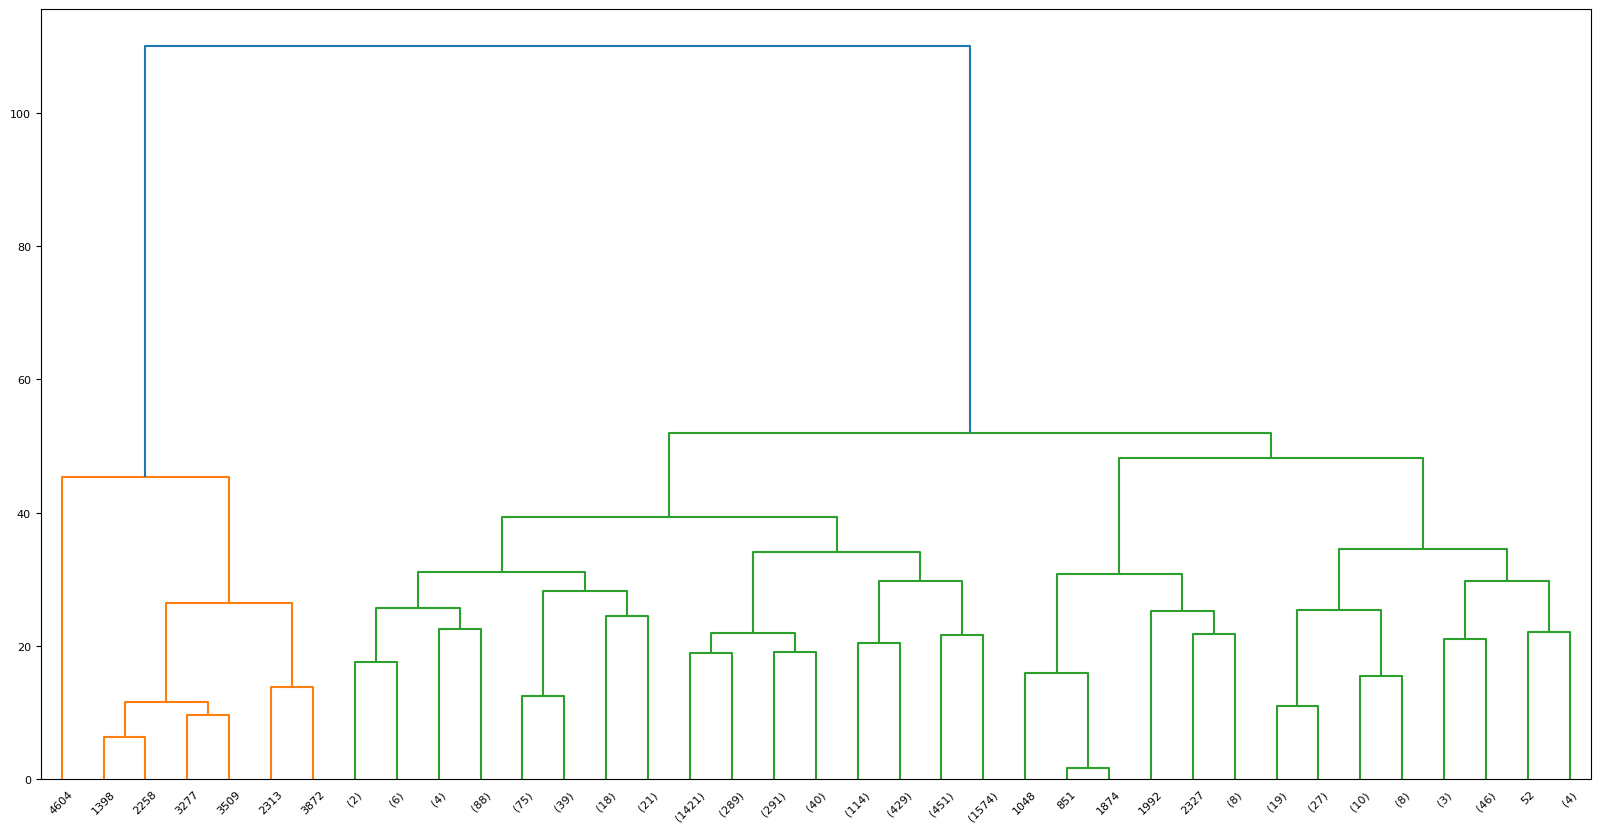

In [10]:
link = linkage(dist_matrix, method='average')
plt.figure(figsize=(20,10))
dendrogram(link, p=5, truncate_mode='level')
labels_hier = fcluster(link, t=60, criterion='distance')
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

In [11]:
d = average_numeric_by_cluster(df, "labels_hier")

shape: (2, 31)
┌─────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┐
│ labels_hier ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c      ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_system_pct ┆ unique_space_groups ┆ top_space_group ┆ top_space_group_pct ┆ unique_anonymized_formulas ┆ top_anonymized_formula ┆ top_a

In [13]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="mace",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-22 16:05:45.272 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:386 - Saved PCA projection plot to figures/materials_project/clustering/euclidean/mace/pca_hierarchical_projection.png


{'coords': array([[ 12.48596722, -14.74005235],
        [-13.63125852,   8.9462165 ],
        [  6.46034269, -15.68300171],
        ...,
        [ -4.73285484,  25.00216307],
        [-15.4144163 ,  -1.1691019 ],
        [-20.86724926,   1.03053731]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/materials_project/clustering/euclidean/mace/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/euclidean/mace'),
 'clustering_method': 'hierarchical'}

In [12]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

# KMedoids

In [14]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)

(array([0, 1, 2], dtype=uint64), array([1677, 2156, 1167]))


In [15]:
d = average_numeric_by_cluster(df, "labels_km")

shape: (3, 32)
┌───────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬─────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┐
│ labels_km ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_system_pct ┆ unique_space_groups ┆ top_space_group ┆ top_space_group_pct ┆ unique_anonymized_formulas ┆ top_

In [16]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="mace",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-22 16:08:39.129 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:386 - Saved PCA projection plot to figures/materials_project/clustering/euclidean/mace/pca_kmedoids_projection.png


{'coords': array([[ 12.48596722, -14.74005235],
        [-13.63125852,   8.9462165 ],
        [  6.46034269, -15.68300171],
        ...,
        [ -4.73285484,  25.00216307],
        [-15.4144163 ,  -1.1691019 ],
        [-20.86724926,   1.03053731]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/materials_project/clustering/euclidean/mace/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/euclidean/mace'),
 'clustering_method': 'kmedoids'}

In [17]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

# Spectral

In [20]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

In [21]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

In [22]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="mace",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-21 11:02:41.321 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/materials_project/clustering/euclidean/mace/pca_spectral_projection.png


{'coords': array([[ -4.42965486,  -8.66439245],
        [ 30.42157934,   2.27176655],
        [ 17.64280794,  15.19923499],
        ...,
        [-18.71784459,   4.51028284],
        [-17.93054394,   6.62245579],
        [-17.12699583,   3.63018153]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/materials_project/clustering/euclidean/mace/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/euclidean/mace'),
 'clustering_method': 'spectral'}

In [17]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 20)
┌─────────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┐
│ labels_spectral ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c      ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ labels_km │
│ ---             ┆ ---   ┆ ---         ┆ ---             ┆ ---                       ┆ ---      ┆ ---     ┆ ---    ┆ ---    ┆ ---    ┆ ---     ┆ ---     ┆ ---     ┆ ---      ┆ ---       ┆ ---               ┆ ---             ┆ ---             ┆ ---         ┆ ---       │
│ i32             ┆ u32   ┆ f64         ┆ f64             ┆ f64                       ┆ f64      ┆ f64     ┆ f64    ┆ f64    ┆ f64    ┆ f64     ┆ f64     ┆ f64     ┆ f64   

# DBSCAN

In [26]:
model_db = DBSCAN(
    eps=0.3,
    min_samples=3,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db,return_counts=True))

(array([-1,  0,  1,  2]), array([  20, 4974,    3,    3]))


In [27]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

In [28]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="mace",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-22 16:10:22.678 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:386 - Saved PCA projection plot to figures/materials_project/clustering/euclidean/mace/pca_dbscan_projection.png


{'coords': array([[ 12.48596722, -14.74005235],
        [-13.63125852,   8.9462165 ],
        [  6.46034269, -15.68300171],
        ...,
        [ -4.73285484,  25.00216307],
        [-15.4144163 ,  -1.1691019 ],
        [-20.86724926,   1.03053731]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/materials_project/clustering/euclidean/mace/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/euclidean/mace'),
 'clustering_method': 'dbscan'}

In [29]:
average_numeric_by_cluster(df, "labels_db")

shape: (4, 33)
┌───────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬────────┬─────────┬─────────┬──────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────┬────────────────────┬────────────────────────┐
│ labels_db ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c      ┆ alpha   ┆ beta    ┆ gamma    ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ labels_km ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_system_pct ┆ unique_space_groups ┆ top_space_group ┆ top_space_group_pct ┆ unique_an

labels_db,count,max_en_diff,energy_per_atom,formation_energy_per_atom,band_gap,density,a,b,c,alpha,beta,gamma,volume,num_sites,energy_above_hull,avg_bond_length,max_bond_length,labels_hier,labels_km,pct_metal,unique_crystal_systems,top_crystal_system,top_crystal_system_pct,unique_space_groups,top_space_group,top_space_group_pct,unique_anonymized_formulas,top_anonymized_formula,top_anonymized_formula_pct,unique_pearson_symbols,top_pearson_symbol,top_pearson_symbol_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,20,1.271,-19.102149,-1.02939,0.159605,8.130619,6.524523,6.246076,6.545126,87.387471,85.743172,85.460011,352.311938,23.35,0.250524,2.272228,2.428117,1.8,1.25,85.0,7,"""Trigonal""",20.0,16,"""P1""",15.0,12,"""AB3""",15.0,18,"""aP102""",10.0
0,4974,1.572696,-13.542861,-1.291756,0.506631,6.225107,6.800149,7.24396,9.522726,86.738395,87.300593,88.655246,427.144012,25.757338,0.082947,2.305569,2.579205,2.0,0.897065,60.514676,7,"""Orthorhombic""",21.431444,174,"""P1""",8.906313,994,"""ABC2""",5.790109,646,"""cF16""",3.216727
1,3,0.546667,-18.142744,-0.086804,0.0,10.650877,3.051971,3.700548,6.101189,90.0,90.0,99.999998,66.095472,7.333333,0.191337,2.061756,2.086489,2.0,0.0,100.0,3,"""Hexagonal""",33.333333,3,"""P6_3/mmc""",33.333333,3,"""AB""",33.333333,3,"""tP6""",33.333333
2,3,2.313333,-8.171638,-3.120637,0.0,8.342079,5.276517,5.276517,5.276517,75.176801,75.176801,54.759727,73.284952,4.666667,0.06154,2.492874,2.526452,1.0,1.0,100.0,3,"""Trigonal""",33.333333,3,"""R-3m""",33.333333,2,"""ABC2""",66.666667,3,"""hR12""",33.333333


# KMeans on Raw Embeddings

In [22]:
X_raw = np.array(df["mace_embedding"].to_list(), dtype=np.float32)
kmeans_raw = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans_raw = kmeans_raw.fit_predict(X_raw)
df = df.with_columns(labels_kmeans_raw=labels_kmeans_raw)

In [26]:
create_chemiscope_viewer(df, X_raw, labels_kmeans_raw, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

In [24]:
average_numeric_by_cluster(df, "labels_kmeans_raw")

shape: (2, 22)
┌───────────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬─────────────────┬───────────┐
│ labels_kmeans_raw ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c      ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ labels_km ┆ labels_spectral ┆ labels_db │
│ ---               ┆ ---   ┆ ---         ┆ ---             ┆ ---                       ┆ ---      ┆ ---     ┆ ---    ┆ ---    ┆ ---    ┆ ---     ┆ ---     ┆ ---     ┆ ---      ┆ ---       ┆ ---               ┆ ---             ┆ ---             ┆ ---         ┆ ---       ┆ ---             ┆ ---       │
│ i32               ┆ u32   ┆ f64         ┆ f64             ┆ f64           